In [23]:
%reset -f
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils import (
    prandtl_number,
    reynolds_number,
    nusselt_number_dittus_boelter,
    liter_per_minute_to_kg_per_s
            )

cell_in_series = 4  # Number of cells in series

# Boundary and initial conditions
T_init = 15  # Initial temperature [C]
T_fluid_in = 15  # Coolant inlet temperature [C]

# Material properties
k_cell_x = 30.0         # thermal conductivity of cell in the plane x-z [W/m·K]
k_cell_z = 30.0         # thermal conductivity of cell in the plane x-z [W/m·K]
k_cell_y = 1.0          # thermal conductivity of cell in the plane y-z [W/m·K]
k_film = 0.2           # thermal conductivity of film [W/m·K] 

rho_cell = 2700.0    # density [kg/m^3] (Close to bulk Aluminum)

# --- Constants ---
length = 0.270 * cell_in_series  # cell length in x [m]
height = 0.104  # cell height in z [m]
thickness = 0.0248  # cell thickness in y [m]
s_film = 0.2e-3  # film thickness [m] (0.1 mm)
volume = length * height * thickness  # cell volume [m^3]

# Coolant properties
cp_water = 33301  # water-glycol [J/kg·K]
mu_water = 0.00339  # dynamic viscosity of water-glycol [Pa.s]
nu_water = mu_water / 1000  # kinematic viscosity of water [m^2/s]
k_water = 0.37  # thermal conductivity of water [W/(m.K)]
mass_flow_rate = liter_per_minute_to_kg_per_s(0.315*cell_in_series)  # flow rate [kg/s] 
volume_flow_rate = mass_flow_rate / 1000  # volume flow rate [m^3/s] (assuming water density ~1000 kg/m^3)
print(f"Flow rate: {mass_flow_rate:.5f} kg/s")

# Cross-sectional area of the coolant channel
s_channel = 2.8 #mm
h_channel = 20 #mm
p_channel = 2*(s_channel + h_channel) * 1e-3  # perimeter of the channel [m]
A_channel = s_channel * h_channel * 1e-6  # cross-sectional area of the channel [m^2]


Flow rate: 0.02100 kg/s


### Evaluation of Heat Transfer Coefficient (HTC)

The next cell calculates the convective heat transfer coefficient (HTC) using the following formulas:

1. **Prandtl Number ($Pr$)**  
    The Prandtl number is a dimensionless quantity that relates the momentum diffusivity to the thermal diffusivity:
    $$
    Pr = \frac{\mu \cdot c_p}{k}
    $$
    where:
    - $\mu$: Dynamic viscosity [Pa·s]
    - $c_p$: Specific heat capacity [J/kg·K]
    - $k$: Thermal conductivity [W/m·K]

2. **Reynolds Number ($Re$)**  
    The Reynolds number is a dimensionless quantity that characterizes the flow regime:
    $$
    Re = \frac{\rho \cdot v \cdot D}{\mu}
    $$
    where:
    - $\rho$: Fluid density [kg/m³]
    - $v$: Flow velocity [m/s]
    - $D$: Hydraulic diameter [m]
    - $\mu$: Dynamic viscosity [Pa·s]

3. **Nusselt Number ($Nu$)**  
    The Nusselt number is a dimensionless quantity that relates convective to conductive heat transfer:
    - For turbulent flow ($Re > 2300$), the Dittus-Boelter equation is used:
      $$
      Nu = 0.023 \cdot Re^{0.8} \cdot Pr^{n}
      \\
      n = 0.3 \text{ for heating, } n = 0.4 \text{ for cooling}
      $$
    - For laminar flow ($Re \leq 2300$), a constant value is assumed:
      $$
      Nu = 3.66
      $$

4. **Convective Heat Transfer Coefficient ($h$)**  
    The HTC is calculated using the Nusselt number:
    $$
    h = \frac{Nu \cdot k}{D}
    $$
    where:
    - $Nu$: Nusselt number
    - $k$: Thermal conductivity [W/m·K]
    - $D$: Hydraulic diameter [m]

In [24]:
# Speed of the coolant
v_coolant = volume_flow_rate / A_channel  # speed of the coolant [m/s]
D_hidraulic = 4 * A_channel / p_channel  # hydraulic diameter of the channel [m]

Pr = prandtl_number(mu_water,cp_water, k_water)
Re = reynolds_number(v_coolant,D_hidraulic,nu_water)
if Re > 2300:
    Nu = nusselt_number_dittus_boelter(Re, Pr)
else:
    Nu = 3.66  # default for fully developed laminar flow in circular tube, constant wall temp

print(f"Hydraulic diameter: {D_hidraulic:.5f} m")
print(f"Coolant speed: {v_coolant:.5f} m/s")
print(f"Prandtl number: {Pr:.2f}")
print(f"Reynolds number: {Re:.2f}")
print(f"Nusselt number: {Nu:.2f}")

#htc_analytic = ((0.68 + (0.67*Re**(1/4))) / ((1+(0.492/Pr)**(9/16))**(4/9))) * k_water / D_hidraulic
#htc_analytic = ((0.825 + (0.387*Re**(1/6))) / ((1+(0.492/Pr)**(9/16)))**(8/27)) * k_water / D_hidraulic
htc_analytic = Nu * k_water / D_hidraulic  # convective heat transfer coefficient [W/(m^2·K)]

print(f"Convective heat transfer coefficient: {htc_analytic:.2f} W/(m^2·K)")

h_conv = htc_analytic  # Convective heat transfer coefficient [W/m^2·K]
h_conv = 800
#h_conv = 180
#h_conv = 1750

Hydraulic diameter: 0.00491 m
Coolant speed: 0.37500 m/s
Prandtl number: 305.11
Reynolds number: 543.39
Nusselt number: 3.66
Convective heat transfer coefficient: 275.68 W/(m^2·K)


### Model Description and Formulas

This section describes the thermal model used to simulate heat transfer and fluid dynamics within a discretized cell. The model incorporates conduction, convection, and heat generation mechanisms to predict temperature distribution and fluid temperature evolution.

#### 1. **Cell Geometry and Discretization**
The cell is modeled as a rectangular prism with dimensions:
- Length ($L$): 0.270 m
- Height ($H$): 0.106 m
- Thickness ($T$): 0.0248 m

The cell is discretized into smaller volumes:
- $n_x$: Number of elements along the $x$-direction.
- $n_y$: Number of elements along the $y$-direction.
- $n_z$: Number of elements along the $z$-direction.

The discretization results in a grid of cells, each with dimensions:
- $\Delta x = \frac{L}{n_x}$
- $\Delta y = \frac{T}{n_y}$
- $\Delta z = \frac{H}{n_z}$


The volume of each discretized cell is:
$$
dV = \frac{L}{n_x} \cdot \frac{T}{n_y} \cdot \frac{H}{n_z}
$$

#### 2. **Thermal Properties**
- **Material Properties**:
    - Thermal conductivity ($k$) in $x$, $y$, and $z$-directions.
    - Density ($\rho$) and specific heat ($c_p$) of the cell material.
- **Coolant Properties**:
    - Specific heat ($c_p$) and flow rate ($\dot{m}$) of the coolant.

#### 3. **Heat Transfer Mechanisms**
- **Conduction**:
    Heat conduction is modeled using thermal resistance:
    $$
    R_{\text{th,cond}} = \frac{\Delta x}{k \cdot \delta A}
    $$
    where $\delta A$ is the cross-sectional area perpendicular to the heat flow $\delta A = \delta_i * \delta_j$.

- **Convection**:
    Convective heat transfer is modeled using:
    $$ 
    R_{\text{th,conv}} = \frac{1}{h \cdot \delta A}
    $$
    where $h$ is the convective heat transfer coefficient.

- **Film Resistance**:
    A thin film layer introduces additional resistance:
    $$ 
    R_{\text{th,film}} = \frac{s_{\text{film}}}{k_{\text{film}} \cdot \delta A}
    $$





Flow rate: 0.02100 kg/s
Mass of each cell: 0.00 kg


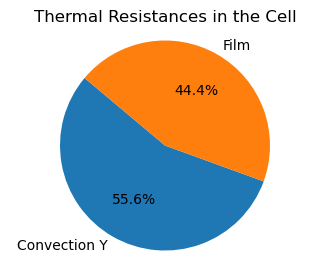

thermal resistance of the film: 1.06838 K/W


In [25]:
# Discretization parameters
nx = 10*cell_in_series # discretization in x
nz = 3  # discretization in z-->!!!!!!!!DO NOT CHANGE THIS VALUE, IT IS A 1D SIMPLIFICATION. Discretize in the presence of thecooling channel
ny = 15  # discretization in y 
dx = length / nx
dz = height / nz
dy = thickness / ny
dV = dx * dy * dz  # volume of each cell [m^3]

# Coolant properties
cp_fluid = 3263  # water [J/kg·K]
print(f"Flow rate: {mass_flow_rate:.5f} kg/s")


m_cell = rho_cell * dV  # mass of each cell [kg]
print(f"Mass of each cell: {m_cell:.2f} kg")
cp_cell = 1040      # specific heat [J/kg·K] (Close to bulk Aluminum)
#alpha = k_cell_x / (rho_cell * cp_cell)  # thermal conductivity [m^2/s]

Rth_cond_x = dx / (k_cell_x*dz*dy)  # thermal resistance in x direction [K/W]
Rth_cond_z = dz / (k_cell_z*dx*dy)  # thermal resistance in x direction [K/W]
Rth_cond_y = dy / (k_cell_y*dx*dz)  # thermal resistance in y direction [K/W]
Rth_conv_y = 1/(h_conv * dx * dz)  # thermal resistance in y direction [K/W]
Rth_film = s_film/(k_film * dz * dx)  # thermal resistance of film [K/W]

#Pie chart of the resistances
resistances_y = {
    'Convection Y': Rth_conv_y,
    'Film': Rth_film
}
plt.figure(figsize=(4, 3))
plt.pie(resistances_y.values(), labels=resistances_y.keys(), autopct='%1.1f%%', startangle=140)
plt.title('Thermal Resistances in the Cell')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

print(f"thermal resistance of the film: {Rth_film:.5f} K/W")

### Temperature Update Mechanism

This section describes how the temperature of the elements and the coolant (water) is updated during the simulation. The updates are based on heat transfer mechanisms and material properties.

#### 1. **Element Temperature Update**
The temperature of each element is updated iteratively using the net heat transfer and the material properties of the element. The formula used is:

- **Temperature Change**:  
    $$
    \Delta T_{\text{element}} = \frac{Q_{\text{net}} \cdot \Delta t}{m_{\text{element}} \cdot c_{p,\text{element}}}
    $$

Here:
- $Q_{\text{net}}$: Net heat transfer for the element, calculated as the sum of conduction, convection, and heat generation.
- $\Delta t$: Time step for the simulation.
- $m_{\text{element}}$: Mass of the element, calculated as $\rho_{\text{element}} \cdot dV$.
- $c_{p,\text{element}}$: Specific heat capacity of the element material.

The updated temperature is then:
$$
T_{\text{element,new}} = T_{\text{element,old}} + \Delta T_{\text{element}}
$$

#### 2. **Coolant (Water) Temperature Update**
The coolant temperature is updated based on the heat transferred from the element to the fluid via convection. The formula used is:

- **Fluid Temperature Change**:  
    $$
    \Delta T_{\text{fluid}} = \frac{Q_{\text{conv}}}{\dot{m} \cdot c_{p,\text{fluid}}}
    $$

Here:
- $Q_{\text{conv}}$: Heat transferred via convection, calculated as:
    $$
    Q_{\text{conv}} = \frac{T_{\text{element}} - T_{\text{fluid}}}{R_{\text{th,conv,y}} + R_{\text{th,film}}}
    $$
- $\dot{m}$: Mass flow rate of the coolant.
- $c_{p,\text{fluid}}$: Specific heat capacity of the coolant.

The next fluid element temprature is then updated as:
$$
T_{\text{fluid,next}} = T_{\text{fluid}} + \Delta T_{\text{fluid}}
$$

#### 3. **Heat Exchange Between Elements**
Heat conduction between neighboring elements is modeled using the thermal resistance in each direction ($x$, $y$, and $z$). The heat transfer between two adjacent elements is calculated as:

- **Conduction Heat Transfer**:  
    $$
    Q_{\text{cond}} = \frac{\Delta T}{R_{\text{th,cond}}}
    $$

Here:
- $\Delta T$: Temperature difference between adjacent elements.
- $R_{\text{th,cond}}$: Thermal resistance in the respective direction, calculated as:
    $$
    R_{\text{th,cond,x}} = \frac{\Delta x}{k_{\text{element,x}} \cdot \delta A}, \quad R_{\text{th,cond,y}} = \frac{\Delta y}{k_{\text{element,y}} \cdot \delta A}, \quad R_{\text{th,cond,z}} = \frac{\Delta z}{k_{\text{element,z}} \cdot \delta A}
    $$

The net heat transfer for each element is the sum of conduction heat transfer from all neighboring elements, convection heat transfer, and internal heat generation. These updates are performed iteratively for each time step to simulate the dynamic thermal behavior of the system.


In [26]:
# Time setup
dt = 1.5 #time step [s]
t_end = 5000  # total time [s]
nt = int(t_end / dt)


Q_tot = 60 * cell_in_series # Total heat generation [W]
q_gen = Q_tot/volume # Heat generation [W/m^3]

# Cross-sectional area for convection (1D simplification)
A_conv = dz * dx  # 1m depth assumed

# --- Initialize temperature field ---
T = np.ones([nx, ny, nz]) * T_init
# --- Functions ---

def convection_loss(T_cell, T_fluid):
    q_conv = (T_cell - T_fluid)/(Rth_conv_y + Rth_film)
    return  q_conv


def update_fluid_temp(T_fluid, q_conv, mass_flow_rate, cp_fluid):
    # m_dot * cp * dT = q_conv  => dT = q_conv / (m_dot * cp)
    m_dot = mass_flow_rate  # [kg/s]
    dT_fluid = 2*q_conv / (m_dot * cp_fluid)

    return T_fluid + dT_fluid


# --- Temperature Field Initialization ---
T = np.ones((nx, ny, nz)) * T_init  # 3D temperature grid
T_hist = np.zeros((nt, nx, ny, nz))  # Temperature history

# --- Fluid Temperature Tracking (z = 0 forward, z = 1 backward)
T_fluid_z0 = np.ones(nx) * T_fluid_in
T_fluid_z1 = np.ones(nx) * T_fluid_in
T_fluid_z2 = np.ones(nx) * T_fluid_in  
t_hist_fluid_z0 = np.zeros((nt, nx))
t_hist_fluid_z1 = np.zeros((nt, nx))
t_hist_fluid_z2 = np.zeros((nt, nx))


# --- Time Loop ---
for t in range(nt):
    T_new = T.copy()
    Q_cond = np.zeros_like(T)

    # --- Conduction: X Direction ---
    for i in range(nx - 1):
        for j in range(ny):
            for k in range(nz):
                dT = T[i + 1, j, k] - T[i, j, k]
                if cell_in_series > 1 and (i == (nx/cell_in_series) or i == 2*nx/cell_in_series or i == 3*nx/cell_in_series or i== 4*nx/cell_in_series):
                    dT = 0  # No conduction to the second layer
                    #print(f"Skipping conduction for last cell in first layer at i={i}, j={j}, k={k}")
                    
                q = dT / Rth_cond_x
                Q_cond[i, j, k] += q
                Q_cond[i + 1, j, k] -= q


    # --- Conduction: Y Direction ---
    for j in range(ny - 1):
        for i in range(nx):
            for k in range(nz):
                dT = T[i, j + 1, k] - T[i, j, k]
                q = dT / Rth_cond_y
                Q_cond[i, j, k] += q
                Q_cond[i, j + 1, k] -= q

    # --- Conduction: Z Direction ---
    for k in range(nz - 1):
        for i in range(nx):
            for j in range(ny):
                dT = T[i, j, k + 1] - T[i, j, k]
                q = dT / Rth_cond_z
                Q_cond[i, j, k] += q
                Q_cond[i, j, k + 1] -= q

    # --- Layer z = 0: Forward fluid flow (left to right)
    for i in range(nx):
        for j in range(ny):
            Q_gen_cell = q_gen * dV
            if j == 0:  # Convection on y = 0
                conv_therm = convection_loss(T[i, j, 0], T_fluid_z0[i]) # Multiply by 2 for both sides of the channel
                Q_net = Q_gen_cell - conv_therm + Q_cond[i, j, 0]
                if i < nx - 1: #update fluid temperature only if not at the last cell and only for the first layer (cooled side)
                    T_fluid_z0[i + 1] = update_fluid_temp(T_fluid_z0[i], conv_therm, mass_flow_rate, cp_fluid)
            else:  # No convection, intenral layer
                Q_net = Q_gen_cell + Q_cond[i, j, 0]

            dT = dt * Q_net / (m_cell * cp_cell)
            T_new[i, j, 0] += dT

    # --- U-turn: Connect fluid from z=0 to z=1
    T_fluid_z1[-1] = T_fluid_z0[-1]

    # --- Layer z = 1: Backward fluid flow (right to left, middle channel)
    for i in reversed(range(nx)):
        for j in range(ny):
            Q_gen_cell = q_gen * dV
            if j == 0:
                conv_therm = convection_loss(T[i, j, 1], T_fluid_z1[i])  # Multiply by 2 for both sides of the channel
                Q_net = Q_gen_cell - conv_therm + Q_cond[i, j, 1]
                if i > 0:
                    T_fluid_z1[i - 1] = update_fluid_temp(T_fluid_z1[i], conv_therm, mass_flow_rate, cp_fluid)
            else:
                Q_net = Q_gen_cell + Q_cond[i, j, 1]

            dT = dt * Q_net / (m_cell * cp_cell)
            T_new[i, j, 1] += dT

    # --- U-turn: Connect fluid from z=0 to z=1
    T_fluid_z2[0] = T_fluid_z1[0]

    # --- Layer z = 2: BForward fluid flow (left to right, bottom channel)
    for i in range(nx):
        for j in range(ny):
            Q_gen_cell = q_gen * dV
            if j == 0:
                conv_therm = convection_loss(T[i, j, 2], T_fluid_z2[i]) # Multiply by 2 for both sides of the channel
                Q_net = Q_gen_cell - conv_therm + Q_cond[i, j, 2]
                if i < nx-1:  # Update fluid temperature only if not at the last cell (i = nx-1) and only for the first layer(j=0) (cooled side)
                    T_fluid_z2[i + 1] = update_fluid_temp(T_fluid_z2[i], conv_therm, mass_flow_rate, cp_fluid)
            else:
                Q_net = Q_gen_cell + Q_cond[i, j, 2]

            dT = dt * Q_net / (m_cell * cp_cell)
            T_new[i, j, 2] += dT

    # --- Save history ---
    T = T_new.copy()
    T_hist[t] = T
    t_hist_fluid_z0[t] = T_fluid_z0.copy()
    t_hist_fluid_z1[t] = T_fluid_z1.copy()
    t_hist_fluid_z2[t] = T_fluid_z2.copy()

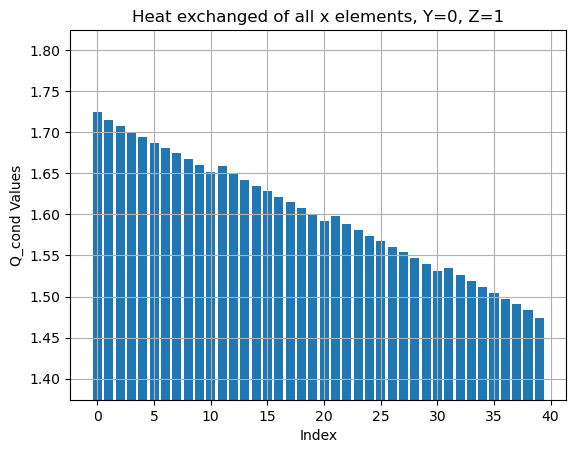

Total heat exchanged in the first layer (z=0, y=0): 159.27 W


In [27]:
bar_values = Q_cond[:, 0, 2]  # Extract the values for the bar chart
x_coords = np.arange(len(bar_values))  # Generate x-coordinates based on the length of bar_values
plt.bar(x_coords, bar_values)  # Plot the bar chart with matching shapes
plt.xlabel("Index")
plt.ylabel("Q_cond Values")
plt.title("Heat exchanged of all x elements, Y=0, Z=1")
plt.ylim(bar_values.min() - 0.1, bar_values.max() + 0.1)
plt.grid(True)
plt.show()
sum_Q_cond = np.sum(Q_cond[:, 0, 1]) + np.sum(Q_cond[:, 0, 0])
print(f"Total heat exchanged in the first layer (z=0, y=0): {sum_Q_cond:.2f} W")

In [28]:
T[:, ny - 1, :].T

array([[47.66068062, 47.66459841, 47.67195611, 47.68197352, 47.69375069,
        47.7063729 , 47.71894369, 47.73058058, 47.74040857, 47.74758574,
        47.75139286, 47.9091355 , 47.91239968, 47.918489  , 47.92668191,
        47.93613634, 47.94598355, 47.95536223, 47.96342965, 47.96938946,
        47.97257128, 48.10902159, 48.11187677, 48.11720023, 48.12435766,
        48.13261102, 48.14120124, 48.14937791, 48.15640832, 48.16160069,
        48.16437252, 48.27969631, 48.28195902, 48.28613663, 48.29165573,
        48.29784327, 48.30400192, 48.30944672, 48.31353759, 48.31574221],
       [47.74379982, 47.74754669, 47.75460338, 47.76423922, 47.77559255,
        47.78777372, 47.79990389, 47.81111809, 47.82056609, 47.82744379,
        47.83108094, 47.9870982 , 47.99019367, 47.99598642, 48.00380464,
        48.01284551, 48.02226791, 48.03123364, 48.03892741, 48.04459172,
        48.04760552, 48.18235778, 48.18504577, 48.19007553, 48.19686211,
        48.20470632, 48.21287632, 48.2206444 , 48.

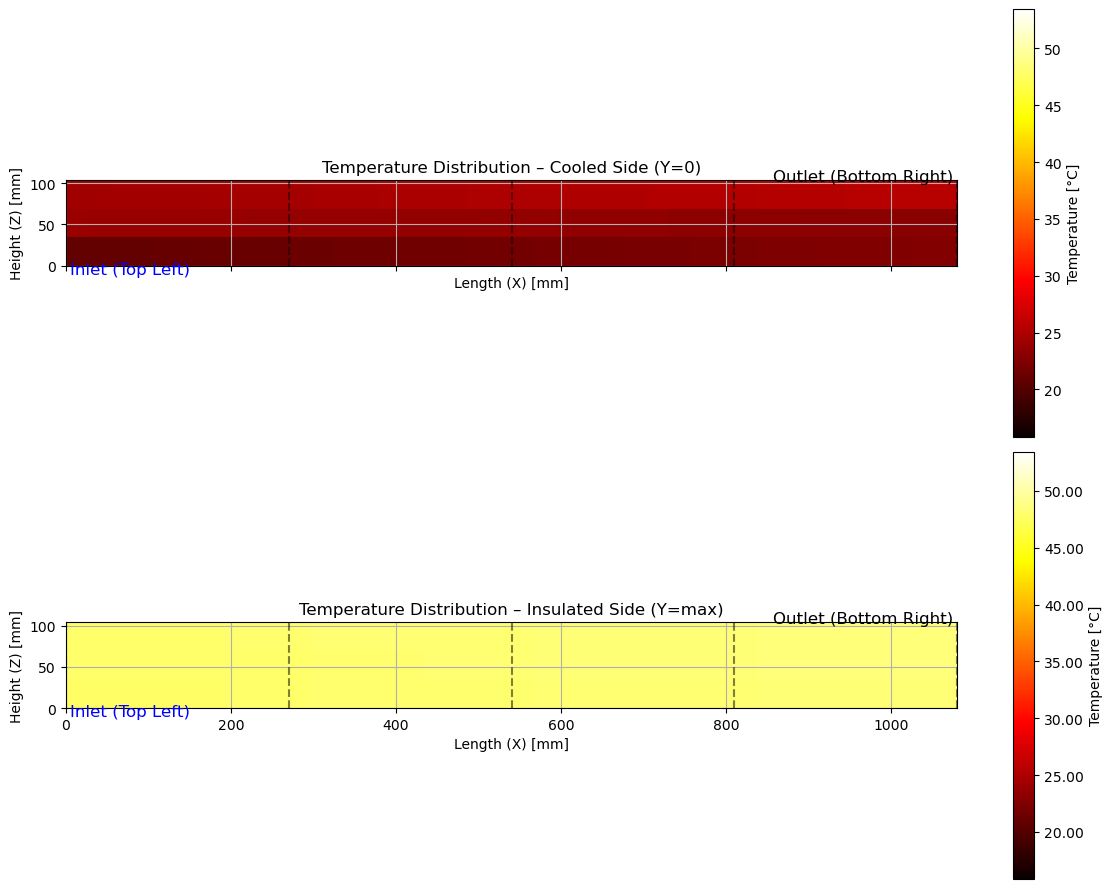

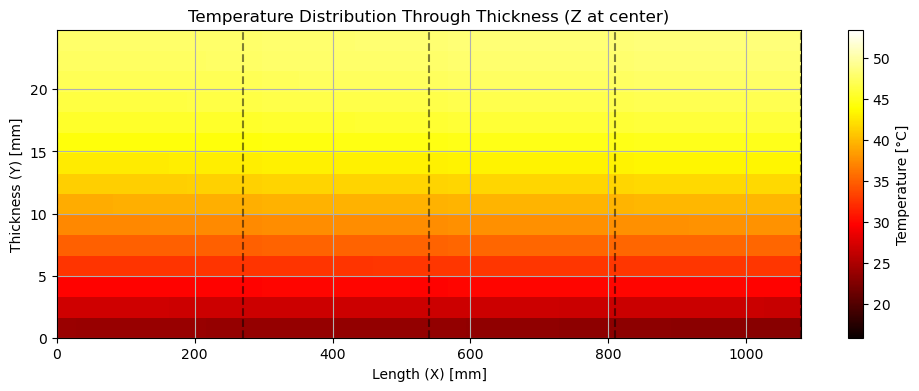

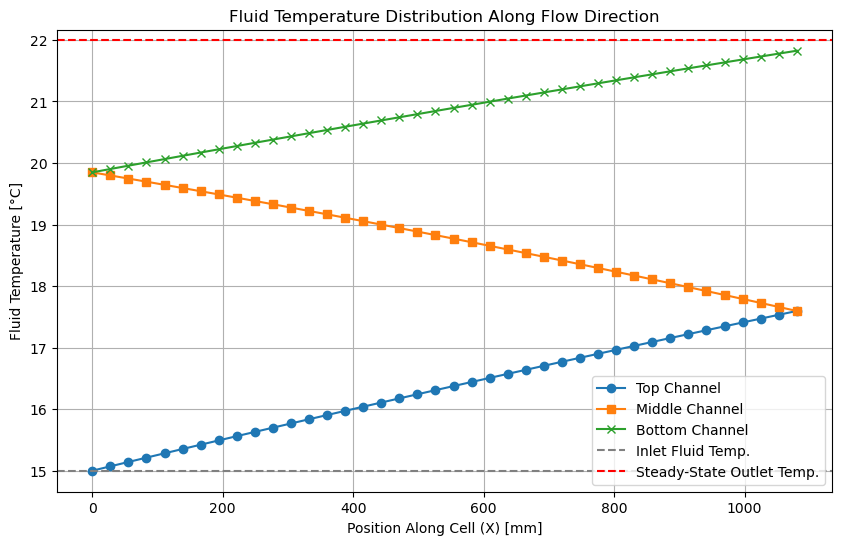

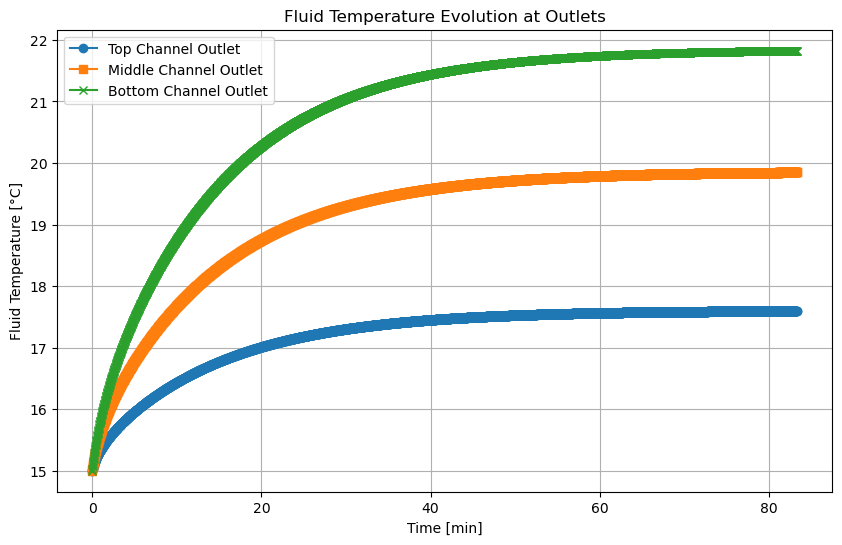

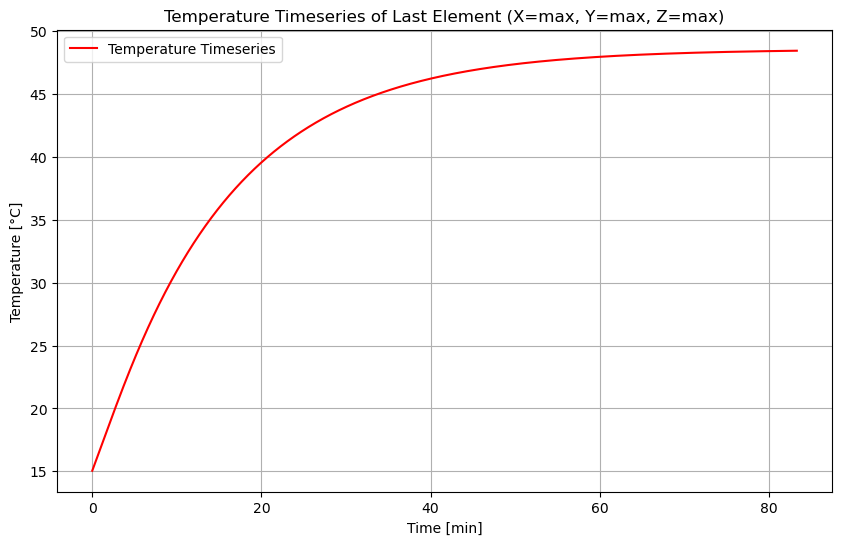

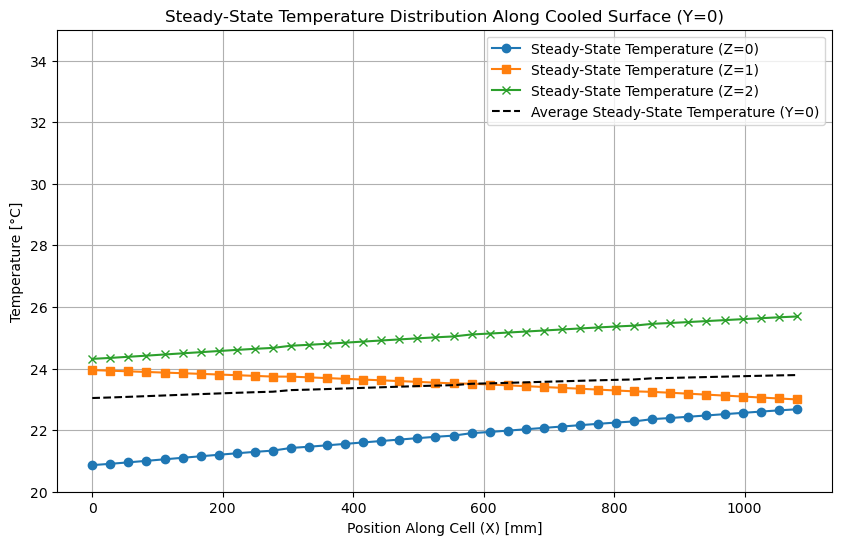

In [37]:
# --- Spatial scaling (in mm) ---
length_mm = nx * dx  * 1000      # Total length in mm
height_mm = height * 1000                        # Z dimension in mm
thickness_mm = thickness * 1000                  # Y dimension in mm

extent_xz = [0, length_mm, 0, height_mm]         # For X-Z slices
extent_xy = [0, length_mm, 0, thickness_mm]      # For X-Y slices

# --- 1. Plot cooled and insulated sides ---
fig, ax = plt.subplots(2, 1, figsize=(12, 9), sharex=True, sharey=True)

# Uniform temperature scale
vmin = T.min()-5
vmax = T.max()+5

# Cooled side (Y=0)
im0 = ax[0].imshow(T[:, 0, :].T, cmap="hot", origin="lower", extent=extent_xz, vmin=vmin, vmax=vmax)
fig.colorbar(im0, ax=ax[0], label="Temperature [°C]")
ax[0].set_title("Temperature Distribution – Cooled Side (Y=0)")
ax[0].set_xlabel("Length (X) [mm]")
ax[0].set_ylabel("Height (Z) [mm]")
ax[0].text(5, 5, "Inlet (Top Left)", color="blue", fontsize=12, ha="left", va="top")
ax[0].text(length_mm - 5, height_mm - 5, "Outlet (Bottom Right)", color="black", fontsize=12, ha="right", va="bottom")
ax[0].grid(True)

# Add vertical lines every length_mm/nx
for x_pos in np.linspace(0, length_mm, cell_in_series + 1):
    ax[0].axvline(x=x_pos, color='black', linestyle='--', alpha=0.5)

# Insulated side (Y=max)
im1 = ax[1].imshow(T[:, ny - 1, :].T, cmap="hot", origin="lower", extent=extent_xz, vmin=vmin, vmax=vmax)
fig.colorbar(im1, ax=ax[1], label="Temperature [°C]", format="%.2f")
ax[1].set_title("Temperature Distribution – Insulated Side (Y=max)")
ax[1].set_xlabel("Length (X) [mm]")
ax[1].set_ylabel("Height (Z) [mm]")
ax[1].text(5, 5, "Inlet (Top Left)", color="blue", fontsize=12, ha="left", va="top")
ax[1].text(length_mm - 5, height_mm - 5, "Outlet (Bottom Right)", color="black", fontsize=12, ha="right", va="bottom")
ax[1].grid(True)

# Add vertical lines every length_mm/nx
for x_pos in np.linspace(0, length_mm, cell_in_series + 1):
    ax[1].axvline(x=x_pos, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()

# --- 2. Plot through-thickness temperature (Y) ---
plt.figure(figsize=(12, 4))
im2 = plt.imshow(T[:, :, nz // 2].T, cmap="hot", origin="lower", extent=extent_xy, aspect='auto', vmin=vmin, vmax=vmax)
plt.colorbar(im2, label="Temperature [°C]")
plt.xlabel("Length (X) [mm]")
plt.ylabel("Thickness (Y) [mm]")
plt.title("Temperature Distribution Through Thickness (Z at center)")
plt.grid(True)

# Add vertical lines every length_mm/nx
for x_pos in np.linspace(0, length_mm, cell_in_series + 1):
    plt.axvline(x=x_pos, color='black', linestyle='--', alpha=0.5)

# --- 3. Fluid temperature profile along X ---
plt.figure(figsize=(10, 6))
x_vals = np.linspace(0, length_mm, nx )
plt.plot(x_vals, T_fluid_z0, label="Top Channel", marker='o')
plt.plot(x_vals, T_fluid_z1, label="Middle Channel", marker='s')
plt.plot(x_vals, T_fluid_z2, label="Bottom Channel", marker='x')

# Reference lines
plt.axhline(y=T_fluid_in, color='gray', linestyle='--', label="Inlet Fluid Temp.")
plt.axhline(
    y=T_fluid_in + 2 * Q_tot / (mass_flow_rate * cp_fluid),
    color='red', linestyle='--', label="Steady-State Outlet Temp."
)

plt.xlabel("Position Along Cell (X) [mm]")
plt.ylabel("Fluid Temperature [°C]")
plt.title("Fluid Temperature Distribution Along Flow Direction")
plt.legend()
plt.grid(True)

# --- 4. Fluid temperature over time ---
plt.figure(figsize=(10, 6))
time_minutes = np.arange(nt) * dt / 60  # Time in minutes
plt.plot(time_minutes, t_hist_fluid_z0[:, -1], label="Top Channel Outlet", marker='o')
plt.plot(time_minutes, t_hist_fluid_z1[:, 0], label="Middle Channel Outlet", marker='s')
plt.plot(time_minutes, t_hist_fluid_z2[:, -1], label="Bottom Channel Outlet", marker='x')

plt.xlabel("Time [min]")
plt.ylabel("Fluid Temperature [°C]")
plt.title("Fluid Temperature Evolution at Outlets")
plt.legend()
plt.grid(True)

plt.show()

# Plot temperature timeseries for the last y plane and last x element
plt.figure(figsize=(10, 6))
time_seconds = np.arange(nt) * dt  # Time in seconds
element_temp_timeseries = T_hist[:, nx - 1, ny - 1, nz - 1]  # Extract temperature timeseries

plt.plot(time_seconds/60, element_temp_timeseries, label="Temperature Timeseries", color='red')
plt.xlabel("Time [min]")
plt.ylabel("Temperature [°C]")
plt.title("Temperature Timeseries of Last Element (X=max, Y=max, Z=max)")
plt.grid(True)
plt.legend()
plt.show()


#Steady state temperature of the coolest surface along x
plt.figure(figsize=(10, 6))
steady_state_temps_0 = T_hist[-1, :, 0, 0]  # Extract the temperature of the coolest surface (Y=0, Z=0) at the last time
steady_state_temps_1 = T_hist[-1, :, 0, 1]  # Extract the temperature of the coolest surface (Y=0, Z=1) at the last time
steady_state_temps_2 = T_hist[-1, :, 0, 2]  # Extract the temperature of the coolest surface (Y=0, Z=2) at the last time

steady_state_temp_avgs = (steady_state_temps_0 + steady_state_temps_1 + steady_state_temps_2) / 3  # Average temperature across z at y=0

x_vals = np.linspace(0, length_mm, nx)  # X-axis values in mm
plt.plot(x_vals, steady_state_temps_0, label="Steady-State Temperature (Z=0)", marker='o')
plt.plot(x_vals, steady_state_temps_1, label="Steady-State Temperature (Z=1)", marker='s')
plt.plot(x_vals, steady_state_temps_2, label="Steady-State Temperature (Z=2)", marker='x')
plt.plot(x_vals, steady_state_temp_avgs, label="Average Steady-State Temperature (Y=0)", color='black', linestyle='--')
plt.xlabel("Position Along Cell (X) [mm]")
plt.ylabel("Temperature [°C]")
plt.title("Steady-State Temperature Distribution Along Cooled Surface (Y=0)")
plt.grid(True)
plt.ylim([20,35])
plt.legend()


In [30]:
# Extract Statistics
max_temp = np.max(T[:, :, :].T)
min_temp = np.min(T[:, :, :].T)
avg_temp = np.mean(T[:, :, :].T)
max_delta_temp = np.max(T[:, :, :].T) - np.min(T[:, :, :].T)

print(f"Max cell Temperature: {max_temp:.2f} °C")
print(f"Min cell Temperature: {min_temp:.2f} °C")
print(f"Average cell Temperature: {avg_temp:.2f} °C")
print(f"Max delta Temperature: {max_delta_temp:.2f} °C")
print()

#Fluid temperature statistics
max_fluid_temp_z0 = np.max(t_hist_fluid_z0[:, -1])
max_fluid_temp_z1 = np.max(t_hist_fluid_z1[:, 0])
avg_fluid_temp = np.mean(t_hist_fluid_z0[:, -1])
print(f"Max Fluid Temperature at z=0: {max_fluid_temp_z0:.2f} °C")
print(f"Max Fluid Temperature at z=1: {max_fluid_temp_z1:.2f} °C")
print(f"Average Fluid Temperature: {avg_fluid_temp:.2f} °C")
print()

#Absolute resistances 
Rth_film_layer_single_cell = s_film/(k_film * length * height)
Rth_conv_single_cell = 1/(h_conv * length * height)  
Rth_tot = (avg_temp - T_fluid_in)/ Q_tot  # Total thermal resistance of the cell [K/W]

print(f"Total thermal resistance of the film: {Rth_film_layer_single_cell:.5f} K/W")
print(f"Convective thermal resistance of the cell: {Rth_conv_single_cell:.5f} K/W")
print(f"Total thermal resistance of the cell: {Rth_tot:.5f} K/W")
print()
# Relative resistances
Rth_film_rel = Rth_film_layer_single_cell / Rth_tot
Rth_conv_rel = Rth_conv_single_cell / Rth_tot
print(f"Relative thermal resistance of the film: {Rth_film_rel*100:.2f} %")
print(f"Relative convective thermal resistance of the cell: {Rth_conv_rel*100:.2f}%")
print("The rest of the thermal resistance is due to conduction in the cell material")
print()

#Equivalent "cooling!" resistance of the entire pack
n_cell_pack = 192
Total_heat_pack = n_cell_pack * Q_tot  # Total heat generation of the pack [W]
print(f"Total heat generation of the pack: {Total_heat_pack:.2f} W")

total_convective_resistance = Rth_conv_single_cell/ (n_cell_pack/ cell_in_series)  # Total convective thermal resistance of the pack [K/W]
total_film_resistance = Rth_film_layer_single_cell / (n_cell_pack/ cell_in_series)  # Total film thermal resistance of the pack [K/W]
total_thermal_resistance = Rth_tot / (n_cell_pack/ cell_in_series)  # Total thermal resistance of the pack [K/W]
print(f"Total convective thermal resistance of the pack: {total_convective_resistance:.5f} K/W")
print(f"Total film thermal resistance of the pack: {total_film_resistance:.5f} K/W")
print(f"Total thermal resistance of the pack: {total_thermal_resistance:.5f} K/W")
# Coductances
total_convective_conductance = 1 / total_convective_resistance  # Total convective conductance of the pack [W/K]
total_film_conductance = 1 / total_film_resistance  # Total film conductance of the pack [W/K]
total_thermal_conductance = 1 / total_thermal_resistance  # Total thermal conductance of the pack [W/K]
print(f"Total convective conductance of the pack: {total_convective_conductance:.5f} W/K")
print(f"Total film conductance of the pack: {total_film_conductance:.5f} W/K")
print(f"Total thermal conductance of the pack: {total_thermal_conductance:.5f} W/K")


Max cell Temperature: 48.46 °C
Min cell Temperature: 20.86 °C
Average cell Temperature: 39.32 °C
Max delta Temperature: 27.59 °C

Max Fluid Temperature at z=0: 17.60 °C
Max Fluid Temperature at z=1: 19.85 °C
Average Fluid Temperature: 17.19 °C

Total thermal resistance of the film: 0.00890 K/W
Convective thermal resistance of the cell: 0.01113 K/W
Total thermal resistance of the cell: 0.10135 K/W

Relative thermal resistance of the film: 8.78 %
Relative convective thermal resistance of the cell: 10.98%
The rest of the thermal resistance is due to conduction in the cell material

Total heat generation of the pack: 46080.00 W
Total convective thermal resistance of the pack: 0.00023 K/W
Total film thermal resistance of the pack: 0.00019 K/W
Total thermal resistance of the pack: 0.00211 K/W
Total convective conductance of the pack: 4313.08800 W/K
Total film conductance of the pack: 5391.36000 W/K
Total thermal conductance of the pack: 473.62620 W/K


### Steady-State Check for Simulation Accuracy

The code checks the correctness of the simulation at steady state by calculating key thermal parameters and comparing them. Below are the steps and formulas used:

1. **Thermal Resistance of the Film**  
    The thermal resistance of the film is calculated using the formula:  
    $$
    R_{\text{th,film,cell}} = \frac{s_{\text{film}}}{k_{\text{film}} \cdot \text{height} \cdot \text{length}}
    $$

2. **Convective Thermal Resistance**  
    The convective thermal resistance is calculated as:  
    $$
    R_{\text{th,convective,cell}} = \frac{1}{h_{\text{conv}} \cdot \text{height} \cdot \text{length}}
    $$

3. **Total Thermal Resistance**  
    The total thermal resistance is the sum of the film and convective resistances:  
    $$
    R_{\text{th,total}} = R_{\text{th,film,cell}} + R_{\text{th,convective,cell}}
    $$

4. **Temperature Difference Between Fluid and Cell**  
    The temperature difference between the fluid and the cell is calculated using:  
    $$
    \Delta T_{\text{Fluid,Cell}} = Q_{\text{tot}} \cdot R_{\text{th,total}}
    $$

5. **Temperature Difference in the Fluid**  
    The temperature difference in the fluid is computed as:  
    $$
    \Delta T_{\text{Fluid}} = \frac{Q_{\text{tot}}}{\dot{m} \cdot c_p}
    $$  
    where $(\dot{m})$ is the mass flow rate and $(c_p)$ is the specific heat capacity of the fluid.

6. **Mean Fluid Temperature**  
    The mean fluid temperature is calculated as:  
    $$
    T_{\text{mean,fluid}} = T_{\text{fluid,in}} + \frac{\Delta T_{\text{Fluid}}}{2}
    $$

7. **Cooled Cell Surface Temperature**  
    The cooled cell surface temperature is determined using:  
    $$
    T_{\text{cooled,surface}} = T_{\text{mean,fluid}} + \Delta T_{\text{Fluid,Cell}}
    $$

8. **Insulated Cell Surface Temperature**  
    The temperature along the cell in the $(y)$-direction is calculated using a linear distribution:  
    $$
    T_x = T_{\text{cooled,surface}} + \frac{q_{\text{spec}}}{k_{\text{cell}}} \left( \frac{\text{thick}^2}{2} - \frac{x^2}{2} \right)
    $$  
    At $(x = 0)$, the insulated cell surface temperature is:  
    $$
    T_{\text{insulated,surface}} = T_{\text{cooled,surface}} + \frac{q_{\text{spec}}}{k_{\text{cell}}} \cdot \frac{\text{thick}^2}{2}
    $$  

These formulas ensure the simulation results align with theoretical steady-state conditions.

Total thermal resistance of the cell: 0.0200 K/W
Temperature difference between fluid and cell: 4.81 °C
Temperature difference in the fluid: 3.50 °C
Mean fluid temperature: 16.75 °C
Cooled cell surface temperature: 21.56 °C


Eq(T_x, T_cooled_surface + q_spec*(thick**2/2 - x**2/2)/k_cell)

Insulated cell surface temperature: 48.05 °C


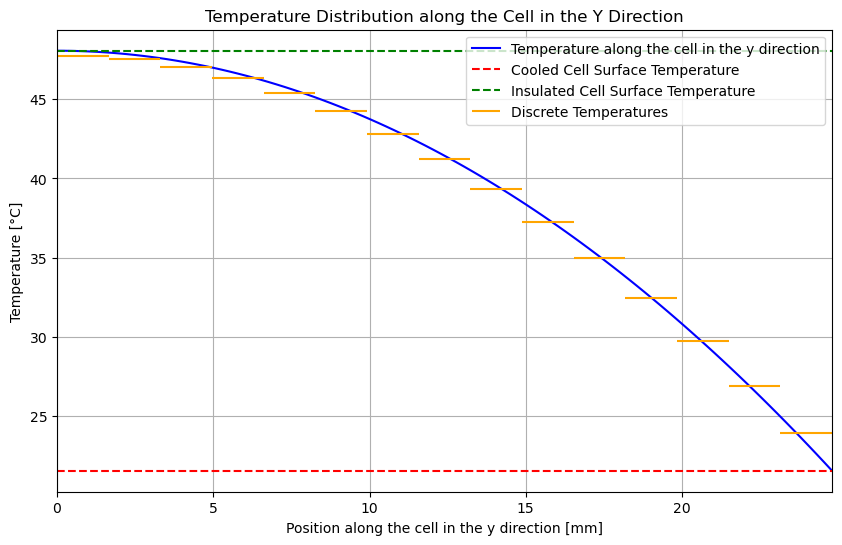

In [31]:
from sympy import symbols, Eq

# Add a check for steady state, to be sure the model is converged
Rth_film_cell = s_film/(k_film * height * length)  # thermal resistance of film [K/W]
Rth_convective_cell = 1/(h_conv * height * length)  # thermal resistance of convection [K/W]
Rth_total = Rth_film_cell + Rth_convective_cell  # total thermal resistance of the cell [K/W]
print(f"Total thermal resistance of the cell: {Rth_total:.4f} K/W")

DeltaT_Fluid_Cell = Q_tot * Rth_total  # Temperature difference in the fluid cell
print(f"Temperature difference between fluid and cell: {DeltaT_Fluid_Cell:.2f} °C")

DeltaT_Fluid = Q_tot/(mass_flow_rate * cp_fluid)  # Temperature difference in the fluid
print(f"Temperature difference in the fluid: {DeltaT_Fluid:.2f} °C")

mean_fluid_temp = T_fluid_in + DeltaT_Fluid/2  # Mean fluid temperature
print(f"Mean fluid temperature: {mean_fluid_temp:.2f} °C")

cooled_cell_surface_temp = mean_fluid_temp + DeltaT_Fluid_Cell  # Cooled cell surface temperature
print(f"Cooled cell surface temperature: {cooled_cell_surface_temp:.2f} °C")

# temeprature along the cell in the y direction
def y_direction_temperature(x, T_cooled_surface, thick, specific_heat, k_cell):
    """
    Calculate the temperature along the cell in the y direction.
    :param x: position along the cell in the x direction [m]
    :return: temperature at position x in the y direction [C]
    """
    if x < 0 or x > length:
        raise ValueError("x must be between 0 and length of the cell")
    
    # Calculate temperature based on linear distribution
    return  specific_heat/k_cell * (-(x**2)/2 + ((thick**2)/2)) + T_cooled_surface

# Define symbolic variables
x, thick, q_spec, k_cell, T_cooled_surface, T_x = symbols('x thick q_spec k_cell T_cooled_surface T_x')

# Define the equation symbolically
temperature_equation = Eq(T_x,q_spec / k_cell * ((-x**2) / 2 + (thick**2 / 2)) + T_cooled_surface)

# Display the equation
display(temperature_equation)

insulated_cell_surface_temp = y_direction_temperature(0, cooled_cell_surface_temp, thickness, q_gen, k_cell_y)
print(f"Insulated cell surface temperature: {insulated_cell_surface_temp:.2f} °C")

# Plot temperature along the cell in the y direction
x_values = np.linspace(0, thickness, 100)
y_temperatures = [y_direction_temperature(x, cooled_cell_surface_temp, thickness, q_gen, k_cell_y) for x in x_values]
plt.figure(figsize=(10, 6))
plt.plot(x_values * 1000, y_temperatures, label="Temperature along the cell in the y direction", color='blue')
plt.axhline(y=cooled_cell_surface_temp, color='red', linestyle='--', label="Cooled Cell Surface Temperature")
plt.axhline(y=insulated_cell_surface_temp, color='green', linestyle='--', label="Insulated Cell Surface Temperature")
plt.xlabel("Position along the cell in the y direction [mm]")
plt.ylabel("Temperature [°C]")
plt.title("Temperature Distribution along the Cell in the Y Direction")

# Overlay discrete temperature points on the same plot
discrete_y_positions = np.arange(ny) * dy * 1000  # Convert to mm
discrete_temperatures = T[0, :, 1]  # Extract temperatures along the y-direction at x=0, z=1

for i, temp in enumerate(discrete_temperatures[::-1]):
    plt.hlines(temp, discrete_y_positions[i]  , discrete_y_positions[i] + dy * 1000 , colors='orange', label="Discrete Temperatures" if i == 0 else "")
plt.xlim(0, thickness * 1000)
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


Thermal Analysis Results:
Total heat generation: 240.00 W
 Equivalent thermal resistance of the cell: 0.11040 K/W

Aluminum Film: 0.4 mm thick
  Total thermal resistance: 0.01115 K/W
  Temperature difference between fluid and cell: 2.68 °C
  Cooled cell surface temperature: 19.43 °C
  Insulated cell surface temperature: 45.92 °C
  Average delta T between fluid and cooled surface temperature: 2.68 °C
  Delta T between insulated surface and cooled surface: 26.50 °C
  Total thermal resistance of the pack: 0.00006 K/W

Plastic Film: 0.2 mm thick
  Total thermal resistance: 0.02003 K/W
  Temperature difference between fluid and cell: 4.81 °C
  Cooled cell surface temperature: 21.56 °C
  Insulated cell surface temperature: 48.05 °C
  Average delta T between fluid and cooled surface temperature: 4.81 °C
  Delta T between insulated surface and cooled surface: 26.50 °C
  Total thermal resistance of the pack: 0.00010 K/W

Plastic Plate:  0.6 mm thick
  Total thermal resistance: 0.03784 K/W
  Tem

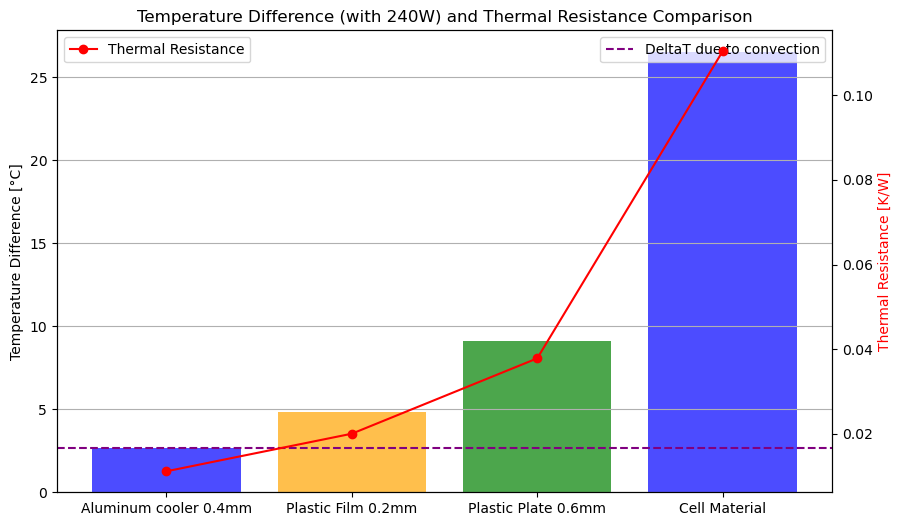

[0.011152659069325735, 0.02003205128205128, 0.03783831908831908, 0.11039886039886039]


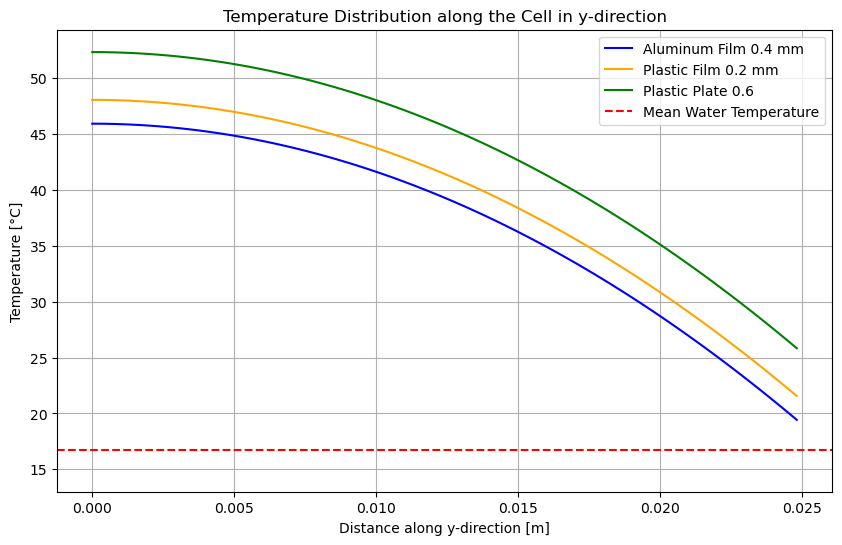

0.011128917378917379


In [32]:
import pandas as pd

k_film_alu = 150 # thermal conductivity of film [W/m·K]
k_film_plastic = 0.2 # thermal conductivity of plastic film [W/m·K]
s_film_alu = 0.4e-3  # film thickness [m] 
s_film_plastic = 0.2e-3  # film thickness [m] 
s_plate_plastic = 0.6e-3  # plate thickness [m] 

# Calculate thermal resistances for aluminum film, plastic film, and plastic plate
Rth_film_alu = s_film_alu / (k_film_alu * height * length)  # Aluminum film resistance [K/W]
Rth_film_plastic = s_film_plastic / (k_film_plastic * height * length)  # Plastic film resistance [K/W]
Rth_plate_plastic = s_plate_plastic / (k_film_plastic * height * length)  # Plastic plate resistance [K/W]

# Calculate total thermal resistances for each case
Rth_total_alu = Rth_film_alu + Rth_convective_cell  # Total resistance for aluminum film [K/W]
Rth_total_plastic_film = Rth_film_plastic + Rth_convective_cell  # Total resistance for plastic film [K/W]
Rth_total_plastic_plate = Rth_plate_plastic + Rth_convective_cell  # Total resistance for plastic plate [K/W]

#Calculate thermal resistance/condtuctances of the Entire Pack
Rth_total_pack_alu = Rth_total_alu / (n_cell_pack)
Rth_total_pack_plastic_film = Rth_total_plastic_film / (n_cell_pack)
Rth_total_pack_plastic_plate = Rth_total_plastic_plate / (n_cell_pack)

# Calculate equivalent conductances for each case
Cth_total_alu = 1 / Rth_total_pack_alu  # Total conductance for aluminum film [W/K]
Cth_total_plastic_film = 1 / Rth_total_pack_plastic_film  # Total conductance for plastic film [W/K]
Cth_total_plastic_plate = 1 / Rth_total_pack_plastic_plate  # Total conductance for plastic plate [W/K]

# Calculate temperature differences between fluid and cell for each case
DeltaT_Fluid_Cell_alu = (Q_tot) * Rth_total_alu  # Aluminum film
DeltaT_Fluid_Cell_plastic_film = (Q_tot) * Rth_total_plastic_film  # Plastic film
DeltaT_Fluid_Cell_plastic_plate = (Q_tot) * Rth_total_plastic_plate  # Plastic plate

# Calculate cooled cell surface temperatures for each case
cooled_cell_surface_temp_alu = mean_fluid_temp + DeltaT_Fluid_Cell_alu  # Aluminum film
cooled_cell_surface_temp_plastic_film = mean_fluid_temp + DeltaT_Fluid_Cell_plastic_film  # Plastic film
cooled_cell_surface_temp_plastic_plate = mean_fluid_temp + DeltaT_Fluid_Cell_plastic_plate  # Plastic plate

# Calculate insulated cell surface temperatures for each case
insulated_cell_surface_temp_alu = y_direction_temperature(0, cooled_cell_surface_temp_alu, thickness, q_gen, k_cell_y)
insulated_cell_surface_temp_plastic_film = y_direction_temperature(0, cooled_cell_surface_temp_plastic_film, thickness, q_gen, k_cell_y)
insulated_cell_surface_temp_plastic_plate = y_direction_temperature(0, cooled_cell_surface_temp_plastic_plate, thickness, q_gen, k_cell_y)

# Calculate Average delta T between fluid and cooled surface temperature
DeltaT_Fluid_cooled_surface_alu = cooled_cell_surface_temp_alu - mean_fluid_temp  # Aluminum film
DeltaT_Fluid_cooled_surface_plastic_film = cooled_cell_surface_temp_plastic_film - mean_fluid_temp  # Plastic film
DeltaT_Fluid_cooled_surface_plastic_plate = cooled_cell_surface_temp_plastic_plate - mean_fluid_temp  # Plastic plate

# Calculate cell delta T
DeltaT_Cell_alu = insulated_cell_surface_temp_alu - cooled_cell_surface_temp_alu  # Aluminum film
DeltaT_Cell_plastic_film = insulated_cell_surface_temp_plastic_film - cooled_cell_surface_temp_plastic_film  # Plastic film
DeltaT_Cell_plastic_plate = insulated_cell_surface_temp_plastic_plate - cooled_cell_surface_temp_plastic_plate  # Plastic plate

# Internal cell equivalent thermal resitance
Rth_single_cell_active_material = (insulated_cell_surface_temp_alu - cooled_cell_surface_temp_alu)/(Q_tot)


# Prepare data for saving
data = {
    "Variable Name": [
        "DeltaT_Fluid_Cell_alu", "DeltaT_Fluid_Cell_plastic_film", "DeltaT_Fluid_Cell_plastic_plate",
        "cooled_cell_surface_temp_alu", "cooled_cell_surface_temp_plastic_film", "cooled_cell_surface_temp_plastic_plate",
        "insulated_cell_surface_temp_alu", "insulated_cell_surface_temp_plastic_film", "insulated_cell_surface_temp_plastic_plate",
        "DeltaT_Fluid_cooled_surface_alu", "DeltaT_Fluid_cooled_surface_plastic_film", "DeltaT_Fluid_cooled_surface_plastic_plate",
        "DeltaT_Cell_alu", "DeltaT_Cell_plastic_film", "DeltaT_Cell_plastic_plate"
    ],
    "Value": [
        DeltaT_Fluid_Cell_alu, DeltaT_Fluid_Cell_plastic_film, DeltaT_Fluid_Cell_plastic_plate,
        cooled_cell_surface_temp_alu, cooled_cell_surface_temp_plastic_film, cooled_cell_surface_temp_plastic_plate,
        insulated_cell_surface_temp_alu, insulated_cell_surface_temp_plastic_film, insulated_cell_surface_temp_plastic_plate,
        DeltaT_Fluid_cooled_surface_alu, DeltaT_Fluid_cooled_surface_plastic_film, DeltaT_Fluid_cooled_surface_plastic_plate,
        DeltaT_Cell_alu, DeltaT_Cell_plastic_film, DeltaT_Cell_plastic_plate
    ]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Save to Excel
df.to_excel("thermal_analysis_results.xlsx", index=False)


# Print Result
print(f"Thermal Analysis Results:")
print(f"Total heat generation: {(Q_tot):.2f} W")
print(f" Equivalent thermal resistance of the cell: {Rth_single_cell_active_material:.5f} K/W")
print()

print(f"Aluminum Film: {s_film_alu*1000} mm thick")
print(f"  Total thermal resistance: {Rth_total_alu:.5f} K/W")
print(f"  Temperature difference between fluid and cell: {DeltaT_Fluid_Cell_alu:.2f} °C")
print(f"  Cooled cell surface temperature: {cooled_cell_surface_temp_alu:.2f} °C")
print(f"  Insulated cell surface temperature: {insulated_cell_surface_temp_alu:.2f} °C")
print(f"  Average delta T between fluid and cooled surface temperature: {DeltaT_Fluid_cooled_surface_alu:.2f} °C")
print(f"  Delta T between insulated surface and cooled surface: {DeltaT_Cell_alu:.2f} °C")
print(f"  Total thermal resistance of the pack: {Rth_total_pack_alu:.5f} K/W")
print()

print(f"Plastic Film: {s_film_plastic*1000} mm thick")
print(f"  Total thermal resistance: {Rth_total_plastic_film:.5f} K/W")
print(f"  Temperature difference between fluid and cell: {DeltaT_Fluid_Cell_plastic_film:.2f} °C")
print(f"  Cooled cell surface temperature: {cooled_cell_surface_temp_plastic_film:.2f} °C")
print(f"  Insulated cell surface temperature: {insulated_cell_surface_temp_plastic_film:.2f} °C")
print(f"  Average delta T between fluid and cooled surface temperature: {DeltaT_Fluid_cooled_surface_plastic_film:.2f} °C")
print(f"  Delta T between insulated surface and cooled surface: {DeltaT_Cell_plastic_film:.2f} °C")
print(f"  Total thermal resistance of the pack: {Rth_total_pack_plastic_film:.5f} K/W")
print()

print(f"Plastic Plate:  {s_plate_plastic*1000} mm thick")
print(f"  Total thermal resistance: {Rth_total_plastic_plate:.5f} K/W")
print(f"  Temperature difference between fluid and cell: {DeltaT_Fluid_Cell_plastic_plate:.2f} °C")
print(f"  Cooled cell surface temperature: {cooled_cell_surface_temp_plastic_plate:.2f} °C")
print(f"  Insulated cell surface temperature: {insulated_cell_surface_temp_plastic_plate:.2f} °C")
print(f"  Average delta T between fluid and cooled surface temperature: {DeltaT_Fluid_cooled_surface_plastic_plate:.2f} °C")
print(f"  Delta T between insulated surface and cooled surface: {DeltaT_Cell_plastic_plate:.2f} °C")
print(f"  Total thermal resistance of the pack: {Rth_total_pack_plastic_plate:.5f} K/W")


# Bar plot all the result to have a comparison with thermal resistance on the left y-axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot temperature differences
labels = [f'Aluminum cooler {s_film_alu*1000}mm', f'Plastic Film {s_film_plastic*1000}mm', f'Plastic Plate {s_plate_plastic*1000}mm', 'Cell Material']
values = [
    DeltaT_Fluid_Cell_alu,
    DeltaT_Fluid_Cell_plastic_film,
    DeltaT_Fluid_Cell_plastic_plate,
    insulated_cell_surface_temp_alu - cooled_cell_surface_temp_alu  # Using aluminum film as reference for cell material
]
ax1.axhline(Rth_convective_cell*Q_tot, color='purple', linestyle='--', label='DeltaT due to convection')
ax1.legend(loc='upper right')
ax1.bar(labels, values, color=['blue', 'orange', 'green'], alpha=0.7)
ax1.set_ylabel('Temperature Difference [°C]', color='black')
ax1.set_title(f'Temperature Difference (with {(Q_tot)}W) and Thermal Resistance Comparison')
ax1.grid(axis='y')

# Add thermal resistance on the left y-axis
thermal_resistances = [
    Rth_total_alu,
    Rth_total_plastic_film,
    Rth_total_plastic_plate,
    Rth_single_cell_active_material  # Using aluminum film as reference for cell material
]
ax2 = ax1.twinx()
ax2.plot(labels, thermal_resistances, color='red', marker='o', linestyle='-', label='Thermal Resistance')
ax2.set_ylabel('Thermal Resistance [K/W]', color='red')
ax2.legend(loc='upper left')
plt.show()

print(thermal_resistances)


# Plot temperature along the cell in the y direction for all three cases
x_values = np.linspace(0, thickness, 100)

# Calculate y-direction temperatures for each case
y_temperatures_alu = [y_direction_temperature(x, cooled_cell_surface_temp_alu, thickness, q_gen, k_cell_y) for x in x_values]
y_temperatures_plastic_film = [y_direction_temperature(x, cooled_cell_surface_temp_plastic_film, thickness, q_gen, k_cell_y) for x in x_values]
y_temperatures_plastic_plate = [y_direction_temperature(x, cooled_cell_surface_temp_plastic_plate, thickness, q_gen, k_cell_y) for x in x_values]

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_temperatures_alu, label=f'Aluminum Film {s_film_alu*1000} mm', color='blue')
plt.plot(x_values, y_temperatures_plastic_film, label=f'Plastic Film {s_film_plastic*1000} mm', color='orange')
plt.plot(x_values, y_temperatures_plastic_plate, label=f'Plastic Plate {s_plate_plastic*1000}', color='green')

# Add mean water temperature as a vertical line
plt.axhline(mean_fluid_temp, color='red', linestyle='--', label='Mean Water Temperature')

plt.xlabel('Distance along y-direction [m]')
plt.ylabel('Temperature [°C]')
plt.title('Temperature Distribution along the Cell in y-direction')
plt.legend()
plt.ylim(T_fluid_in - 2, max(y_temperatures_alu + y_temperatures_plastic_film + y_temperatures_plastic_plate) + 2)
plt.grid()
plt.show()

print(Rth_convective_cell)

In [33]:
#%matplotlib notebook
import matplotlib.animation as animation
animation_flag = 0  # Set to 1 to enable animation, 0 to disable
if animation_flag == 1:
    fig, ax = plt.subplots(figsize=(10, 6))
    extent = [0, length * 1000, 0, height * 1000]  # For consistent mm scale
    im = ax.imshow(T_hist[0], cmap="hot", origin="lower", extent=extent, vmin=np.min(T_hist), vmax=np.max(T_hist))
    cbar = plt.colorbar(im, ax=ax, label="Temperature [°C]")
    ax.set_xlabel("Length (X) [mm]")
    ax.set_ylabel("Height (Z) [mm]")
    ax.set_title("Temperature Evolution in Cell")
    ax.grid(True)

    def update(frame):
        im.set_array(T_hist[frame])
        ax.set_title(f"Time: {frame*dt:.1f} s")
        return [im]

    ani = animation.FuncAnimation(fig, update, frames=nt, interval=30, blit=True)
    ani.save("temperature_evolution.mp4", writer="ffmpeg", fps=30)